In [81]:
import sympy as sp
from sympy import (
    symbols, Function, cos, sin, Rational,
    Matrix, simplify, trigsimp, diff, solve, expand,
    sqrt, pi, Eq, latex,
)
from IPython.display import display, Math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.integrate import solve_ivp

# Energy-Based Control of the Cart-Pole System

## Table of Contents
1. **System Modeling** — Lagrangian derivation of equations of motion
2. **Energy Conservation** — Proof that $\dot{E} = 0$ when $u = 0$ (marginal stability)
3. **Periodicity** — Proof that unforced trajectories are periodic
4. **Energy–Velocity Relation** — Proof that $\dot{E} = u\dot{x}$
5. **Lyapunov Control Design** — Full-energy Lyapunov function and convergence
6. **Saturation Robustness** — Proof that $\dot{V}\leq 0$ under any control bound

---

## Conventions

| Symbol | Meaning |
|--------|---------|
| $x(t)$ | Cart position |
| $\theta(t)$ | Pendulum angle, **$\theta=0$ is upright** |
| $m_c$ | Cart mass |
| $m_p$ | Pendulum (point) mass |
| $l$ | Pendulum length (to center of mass) |
| $g$ | Gravitational acceleration |
| $a$ | Horizontal force applied to the cart |

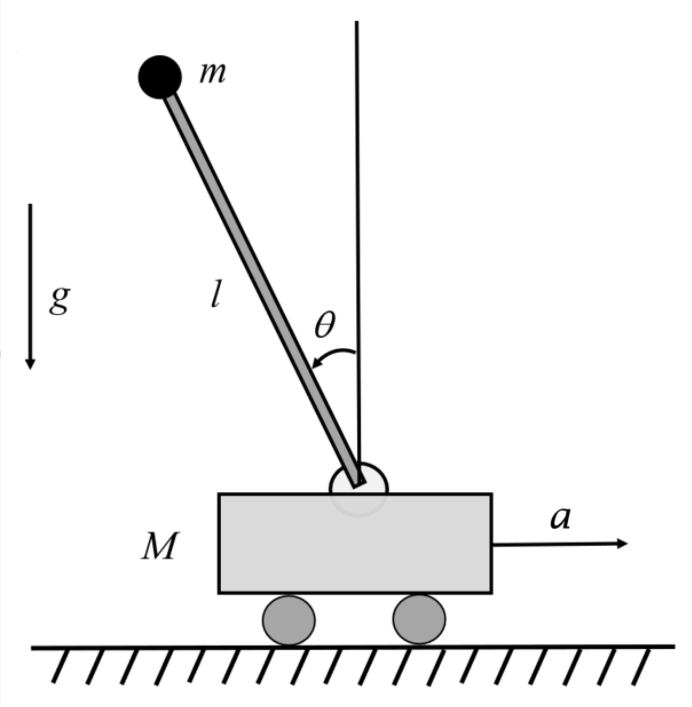

In [2]:
# Cell 3 — Define symbols
t = symbols("t")

x = Function("x")(t)
theta = Function("theta")(t)

x_d = diff(x, t)
x_dd = diff(x, t, 2)
theta_d = diff(theta, t)
theta_dd = diff(theta, t, 2)

m_c, m_p, l, g = symbols("m_c m_p l g", positive=True, real=True)
a = symbols("a")
k_E = symbols("k_E", positive=True, real=True)
E_tilde = symbols(r"\tilde{E}", real=True)

---
## 1. System Modeling — Lagrangian Derivation

### 1.1 Positions

The cart moves along the $x$-axis. The pendulum mass is located at:

$$x_p = x + l\sin\theta, \qquad y_p = l\cos\theta$$

where $\theta = 0$ corresponds to the **upright** position.

In [3]:
x_p = x + l * sin(theta)
y_p = l * cos(theta)

vx_p = diff(x_p, t)
vy_p = diff(y_p, t)

print("Pendulum velocity components:")
display(Math(r"\dot{x}_p = " + latex(vx_p)))
display(Math(r"\dot{y}_p = " + latex(vy_p)))

Pendulum velocity components:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 1.2 Kinetic Energy

$$T = \underbrace{\tfrac{1}{2}m_c\dot{x}^2}_{\text{cart}} + \underbrace{\tfrac{1}{2}m_p\bigl(\dot{x}_p^2 + \dot{y}_p^2\bigr)}_{\text{pendulum}}$$

In [4]:
T_cart = Rational(1, 2) * m_c * x_d**2
T_pend = Rational(1, 2) * m_p * (vx_p**2 + vy_p**2)
T = T_cart + T_pend

print("Kinetic energy (raw, expanded):")
T_expanded = sp.expand(T)
display(Math(r"T = " + latex(T_expanded)))

print("\nKinetic energy (simplified with trig identities):")
T_simplified = trigsimp(T_expanded)
display(Math(r"T = " + latex(T_simplified)))

Kinetic energy (raw, expanded):


<IPython.core.display.Math object>


Kinetic energy (simplified with trig identities):


<IPython.core.display.Math object>

### 1.3 Potential Energy

With $\theta = 0$ upright, the height of the pendulum mass is $y_p = l\cos\theta$:

$$V = m_p g l \cos\theta$$

- Upright ($\theta = 0$): $V = m_p g l$ (maximum)
- Hanging ($\theta = \pi$): $V = -m_p g l$ (minimum)

In [5]:
V = m_p * g * y_p  # = m_p * g * l * cos(theta)
V_simplified = trigsimp(V)

print("Potential energy:")
display(Math(r"V = " + latex(V_simplified)))

Potential energy:


<IPython.core.display.Math object>

### 1.4 Lagrangian

$$\mathcal{L} = T - V$$

In [6]:
L = T_simplified - V_simplified
L = trigsimp(sp.expand(L))

print("Lagrangian:")
display(Math(r"\mathcal{L} = " + latex(L)))

Lagrangian:


<IPython.core.display.Math object>

### 1.5 Euler–Lagrange Equations

For generalized coordinate $q$ with generalized force $Q$:

$$\frac{d}{dt}\frac{\partial \mathcal{L}}{\partial \dot{q}} - \frac{\partial \mathcal{L}}{\partial q} = Q$$

- For $x$: $\;Q_x = a$ (external force on the cart)
- For $\theta$: $\;Q_\theta = 0$ (no external torque)

In [7]:
def euler_lagrange(L, q, q_dot, Q):
    """Compute EL equation: d/dt(dL/dq_dot) - dL/dq - Q = 0."""
    dL_dqd = diff(L, q_dot)
    dt_dL_dqd = diff(dL_dqd, t)
    dL_dq = diff(L, q)
    return dt_dL_dqd - dL_dq - Q

# --- x equation ---
EL_x_raw = euler_lagrange(L, x, x_d, a)

print("EL equation for x (raw):")
display(Math(r"0 = " + latex(sp.expand(EL_x_raw))))

EL_x = trigsimp(sp.expand(EL_x_raw))
print("\nEL equation for x (simplified):")
display(Math(r"0 = " + latex(EL_x)))

# --- theta equation ---
EL_theta_raw = euler_lagrange(L, theta, theta_d, 0)

print("\nEL equation for theta (raw):")
display(Math(r"0 = " + latex(sp.expand(EL_theta_raw))))

EL_theta = trigsimp(sp.expand(EL_theta_raw))
print("\nEL equation for theta (simplified):")
display(Math(r"0 = " + latex(EL_theta)))

EL equation for x (raw):


<IPython.core.display.Math object>


EL equation for x (simplified):


<IPython.core.display.Math object>


EL equation for theta (raw):


<IPython.core.display.Math object>


EL equation for theta (simplified):


<IPython.core.display.Math object>

### 1.6 Solve for Accelerations $\ddot{x}$ and $\ddot{\theta}$

We solve the two coupled EL equations simultaneously for $\ddot{x}$ and $\ddot{\theta}$.

In [8]:
sol = solve([EL_x, EL_theta], [x_dd, theta_dd])

x_dd_expr = sol[x_dd]
theta_dd_expr = sol[theta_dd]

print("x_ddot (raw from solve):")
display(Math(r"\ddot{x} = " + latex(x_dd_expr)))

print("\ntheta_ddot (raw from solve):")
display(Math(r"\ddot{\theta} = " + latex(theta_dd_expr)))

# Simplify
x_dd_expr = simplify(x_dd_expr)
theta_dd_expr = simplify(theta_dd_expr)

print("\nx_ddot (simplified):")
display(Math(r"\ddot{x} = " + latex(x_dd_expr)))

print("\ntheta_ddot (simplified):")
display(Math(r"\ddot{\theta} = " + latex(theta_dd_expr)))

x_ddot (raw from solve):


<IPython.core.display.Math object>


theta_ddot (raw from solve):


<IPython.core.display.Math object>


x_ddot (simplified):


<IPython.core.display.Math object>


theta_ddot (simplified):


<IPython.core.display.Math object>

---
## 2. Energy Conservation — Marginal Stability

### 2.1 Total Mechanical Energy

$$E_{\text{total}} = T + V$$

In [9]:
E_total = T_simplified + V_simplified

print("Total mechanical energy:")
display(Math(r"E_{\text{total}} = " + latex(E_total)))

Total mechanical energy:


<IPython.core.display.Math object>

### 2.2 Time Derivative of Energy

We compute $\dot{E}_{\text{total}} = \frac{d}{dt}E_{\text{total}}$ in three stages:

1. **Raw differentiation** — apply the chain rule
2. **Substitute EOM** — replace $\ddot{x}$ and $\ddot{\theta}$ with the expressions found above
3. **Simplify** — use trigonometric identities

In [10]:
E_dot_raw = diff(E_total, t)

print("Stage 1 — Raw dE/dt (chain rule only):")
display(Math(r"\dot{E} = " + latex(sp.expand(E_dot_raw))))

Stage 1 — Raw dE/dt (chain rule only):


<IPython.core.display.Math object>

In [11]:
E_dot_sub = E_dot_raw.subs(x_dd, x_dd_expr).subs(theta_dd, theta_dd_expr)

print("Stage 2 — After substituting EOM (before simplification):")
display(Math(r"\dot{E} = " + latex(E_dot_sub)))

Stage 2 — After substituting EOM (before simplification):


<IPython.core.display.Math object>

In [12]:
E_dot_simplified = trigsimp(sp.expand(E_dot_sub))

print("Stage 3 — After trigonometric simplification:")
display(Math(r"\dot{E}_{\text{total}} = " + latex(E_dot_simplified)))

Stage 3 — After trigonometric simplification:


<IPython.core.display.Math object>

### 2.3 Energy Conservation when $a = 0$

In [13]:
E_dot_free = trigsimp(E_dot_simplified.subs(a, 0))

print("dE/dt with a = 0:")
display(Math(r"\left.\dot{E}_{\text{total}}\right|_{a=0} = " + latex(E_dot_free)))

dE/dt with a = 0:


<IPython.core.display.Math object>

### 2.4 Interpretation: Marginal Stability

We have proved that for the unforced system ($a = 0$):

$$\dot{E}_{\text{total}} = 0 \quad \Longrightarrow \quad E_{\text{total}}(t) = E_{\text{total}}(0) \;\;\forall\, t$$

**Consequences:**

| Step | Claim | Reason |
|------|-------|--------|
| 1 | $E_{\text{total}}$ is constant | $\dot{E} = 0$ (just proved) |
| 2 | Potential energy is bounded: $-m_pgl \leq V \leq m_pgl$ | $V = m_pgl\cos\theta$ |
| 3 | Kinetic energy is bounded: $0 \leq T \leq E_{\text{total}} + m_pgl$ | $T = E_{\text{total}} - V$ |
| 4 | $\dot\theta$ is bounded | $\frac{1}{2}m_pl^2\dot\theta^2 \leq T$ |
| 5 | Trajectories are bounded | All state variables bounded |
| 6 | No convergence to equilibrium | No dissipation mechanism |

$$\boxed{\text{Bounded trajectories + no convergence} = \textbf{Marginal Stability}}$$

---
## 3. Periodicity and Phase Portrait Analysis

We want to prove that the unforced ($a = 0$) cart-pole system has periodic trajectories.

### 3.1 Why Pendulum Energy vs. Total Energy?

A natural question: we defined $E_{\text{total}}$ for the full system — why do we now
look at the pendulum alone?

**The key insight:** when $a = 0$, the total energy $E_{\text{total}}$ is conserved,
but it includes the cart's kinetic energy $\frac{1}{2}m_c\dot{x}^2$. The cart
can drift indefinitely (translate at constant velocity), so the **full state**
$(x, \dot{x}, \theta, \dot\theta)$ may never return to its initial value.

However, the **pendulum subsystem** $(\theta, \dot\theta)$ does exhibit periodic
motion. To see this clearly, we analyze three cases:

| System | Periodic in $(x, \dot{x})$? | Periodic in $(\theta, \dot\theta)$? |
|--------|-----------------------------|--------------------------------------|
| Free cart-pole ($a=0$) | ❌ Cart drifts | ✅ Pendulum oscillates |
| Fixed-pivot pendulum | N/A | ✅ Pendulum oscillates |
| Cart-pole with centering | ✅ (bounded) | ✅ Pendulum oscillates |

For periodicity, we focus on $(\theta, \dot\theta)$ — the degrees of freedom
that exhibit closed orbits.

**But first**, let us verify this claim using phase portraits of the **full nonlinear system**.

In [51]:
# Physical parameters
params = {
    "m_c": 1.0,   # cart mass [kg]
    "m_p": 0.3,   # pendulum mass [kg]
    "l":   0.5,   # pendulum length [m]
    "g":   9.81,  # gravity [m/s^2]
}

def cart_pole_dynamics(t, state, p, a_func=None):
    """
    Full nonlinear cart-pole dynamics.
    state = [x, x_dot, theta, theta_dot]
    theta = 0 is upright.
    """
    x, x_dot, th, th_dot = state
    mc, mp, l, g = p["m_c"], p["m_p"], p["l"], p["g"]

    a = 0.0 if a_func is None else a_func(t, state)

    sin_th = np.sin(th)
    cos_th = np.cos(th)
    delta = mc + mp * sin_th**2

    x_ddot = (a + mp * l * th_dot**2 * sin_th
              - mp * g * sin_th * cos_th) / delta

    th_ddot = (-a * cos_th - mp * l * th_dot**2 * sin_th * cos_th
               + (mc + mp) * g * sin_th) / (delta * l)

    return [x_dot, x_ddot, th_dot, th_ddot]


def total_energy(state, p):
    """E_total = T + V for the cart-pole."""
    x, x_dot, th, th_dot = state
    mc, mp, l, g = p["m_c"], p["m_p"], p["l"], p["g"]

    T = (0.5 * (mc + mp) * x_dot**2
         + 0.5 * mp * l**2 * th_dot**2
         + mp * l * x_dot * th_dot * np.cos(th))
    V = mp * g * l * (1+np.cos(th))
    return T + V


def pendulum_energy(state, p):
    """Pendulum-only energy: E_p = 0.5*m_p*(l*th_dot)^2 + m_p*g*l*(1 - cos(th))
    with theta measured from upright, shifted so E_p=0 at bottom."""
    _, _, th, th_dot = state
    mp, l, g = p["m_p"], p["l"], p["g"]
    return 0.5 * mp * (l * th_dot)**2 + mp * g * l * (1.0 + np.cos(th))

In [56]:
total_energy([0,np.sqrt(params["g"]*params["l"]*params["m_p"]*2/(params["m_c"]+params["m_p"])),np.pi/2,0], params)

2.9429999999999996

### 3.2 Phase Portrait of the Full System (Unforced)

We simulate the unforced system from multiple initial conditions and plot:
1. The **pendulum phase portrait** $(\theta, \dot\theta)$
2. The **cart phase portrait** $(x, \dot x)$
3. Time histories of energy

This will visually demonstrate:
- Pendulum trajectories are **closed orbits** → periodic
- Cart trajectories **drift** → not periodic
- Total energy is **conserved**

In [74]:
# Cell — Simulate from multiple initial conditions

# Initial conditions: vary pendulum angle, cart starts at rest
initial_conditions = [
    # [x, x_dot, theta, theta_dot]  — label
    ([0.0, 0.0, np.pi - 0.3, 0.0], "Small osc. (θ₀=π−0.3)"),   # small swing near bottom
    ([0.0, 0.0, np.pi - 1., 0.0], "Medium osc. (θ₀=π−1.0)"),  # medium swing
    ([0.0, 0.0, np.pi - 2.5, 0.0], "Large osc. (θ₀=π−2.5)"),   # large swing
    ([0.0, 0.0, 0.04, 0.0], "Near separatrix (θ₀≈0.04)"),  # near separatrix
    ([0, 0.0, np.pi - 1., 0.5], r"With pendulum vel. ($\dotθ$₀=0.5)"),  # nonzero pendulum velocity
    ([0, 0.0, np.pi/2, np.sqrt(2*params["g"]/params["l"])], r"With pendulum vel. ($\dotθ$₀=0.5)"),  # full energy in pendulum
]

t_span = (0, 15)
t_eval = np.linspace(*t_span, 5000)

results = []
for ic, label in initial_conditions:
    sol = solve_ivp(
        cart_pole_dynamics, t_span, ic,
        args=(params,), t_eval=t_eval,
        method="RK45", rtol=1e-10, atol=1e-12,
    )
    E_tot = np.array([total_energy(sol.y[:, i], params) for i in range(len(sol.t))])
    E_pen = np.array([pendulum_energy(sol.y[:, i], params) for i in range(len(sol.t))])
    results.append({
        "sol": sol, "label": label, "ic": ic,
        "E_total": E_tot, "E_pend": E_pen,
    })

print(f"Simulated {len(results)} trajectories over t ∈ [{t_span[0]}, {t_span[1]}] s")

Simulated 6 trajectories over t ∈ [0, 15] s


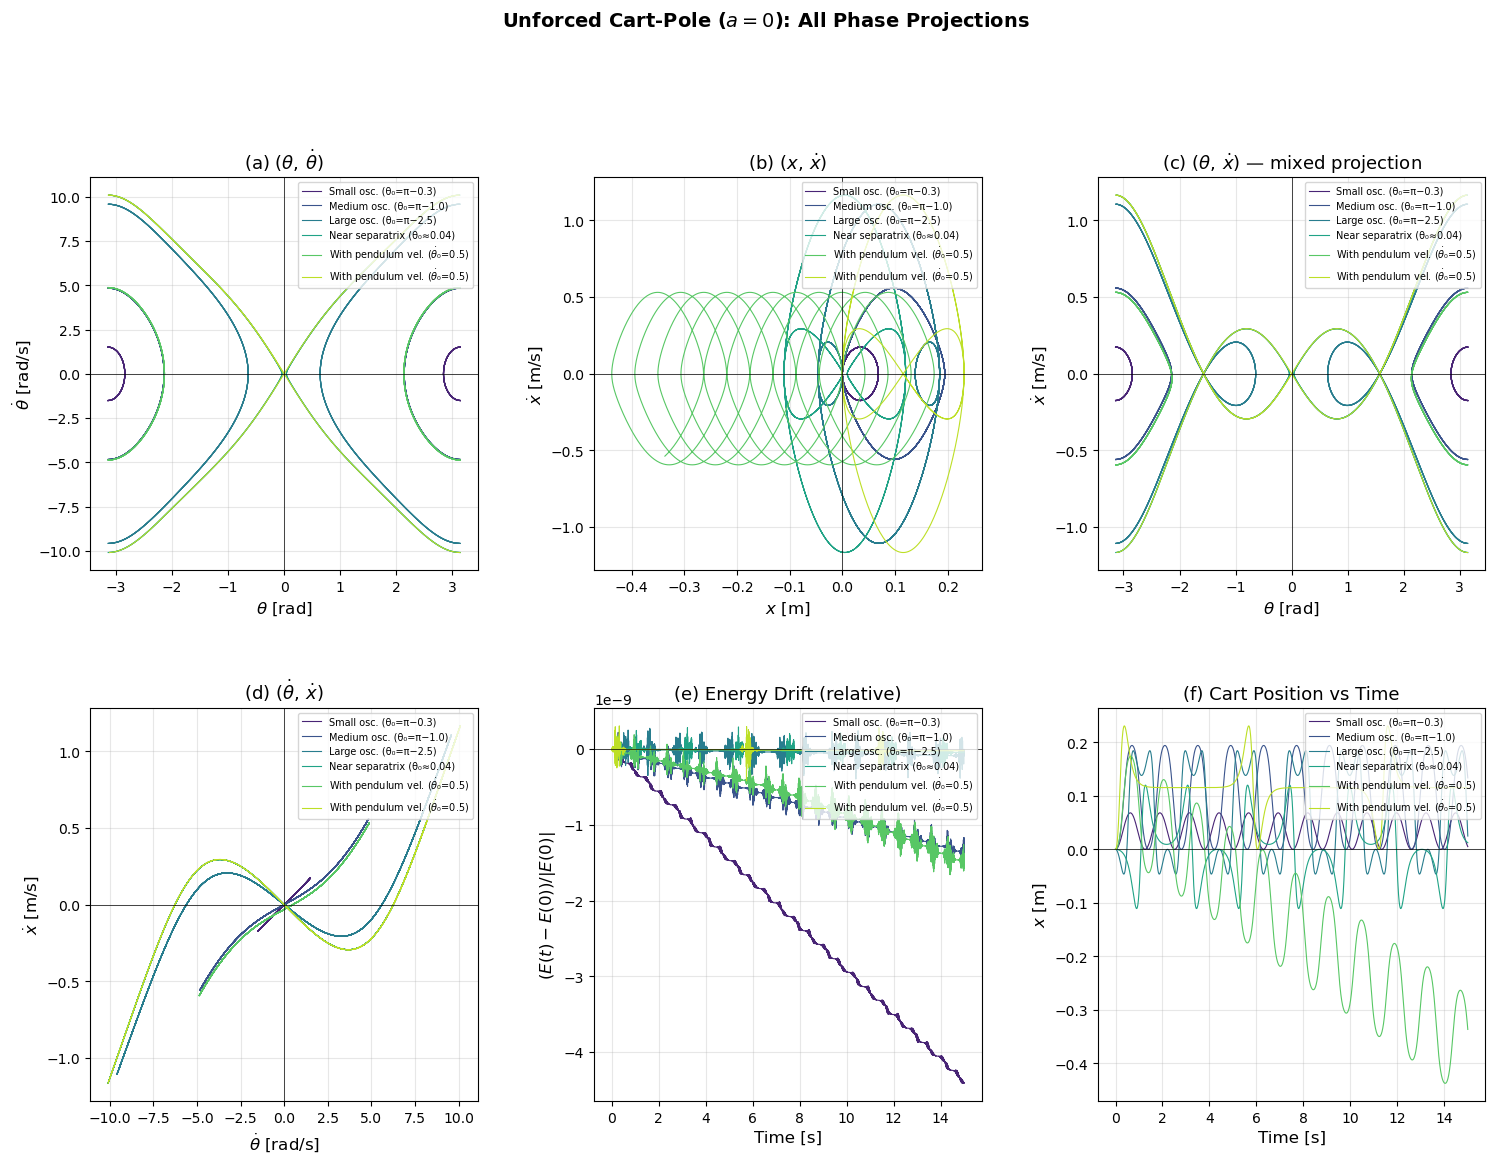

In [75]:
# Cell — REPLACE the phase portrait cell (fixes vertical lines + adds new projections)

def split_at_wraps(th, *others, threshold=5.0):
    """
    Split arrays at points where theta wraps around.
    Returns list of segments.
    """
    dth = np.abs(np.diff(th))
    wrap_idx = np.where(dth > threshold)[0] + 1
    indices = np.concatenate(([0], wrap_idx, [len(th)]))
    segments = []
    for i in range(len(indices) - 1):
        s = slice(indices[i], indices[i + 1])
        segments.append((th[s],) + tuple(o[s] for o in others))
    return segments


fig = plt.figure(figsize=(18, 12))
gs = GridSpec(2, 3, hspace=0.35, wspace=0.3)

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(results)))

# ── (a) Pendulum phase portrait (θ, θ̇) — with broken wraps ──
ax1 = fig.add_subplot(gs[0, 0])
for r, c in zip(results, colors):
    sol = r["sol"]
    th_wrapped = (sol.y[2] + np.pi) % (2 * np.pi) - np.pi
    segments = split_at_wraps(th_wrapped, sol.y[3])
    for i, (th_seg, thd_seg) in enumerate(segments):
        ax1.plot(th_seg, thd_seg, color=c, linewidth=0.8,
                 label=r["label"] if i == 0 else None)

ax1.set_xlabel(r"$\theta$ [rad]", fontsize=12)
ax1.set_ylabel(r"$\dot{\theta}$ [rad/s]", fontsize=12)
ax1.set_title(r"(a) $(\theta,\,\dot\theta)$", fontsize=13)
ax1.legend(fontsize=7, loc="upper right")
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color="k", linewidth=0.5)
ax1.axvline(0, color="k", linewidth=0.5)

# ── (b) Cart phase portrait (x, ẋ) ──
ax2 = fig.add_subplot(gs[0, 1])
for r, c in zip(results, colors):
    sol = r["sol"]
    ax2.plot(sol.y[0], sol.y[1], color=c, linewidth=0.8, label=r["label"])

ax2.set_xlabel(r"$x$ [m]", fontsize=12)
ax2.set_ylabel(r"$\dot{x}$ [m/s]", fontsize=12)
ax2.set_title(r"(b) $(x,\,\dot{x})$", fontsize=13)
ax2.legend(fontsize=7, loc="upper right")
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color="k", linewidth=0.5)
ax2.axvline(0, color="k", linewidth=0.5)

# ── (c) Mixed phase portrait (θ, ẋ) ──
ax3 = fig.add_subplot(gs[0, 2])
for r, c in zip(results, colors):
    sol = r["sol"]
    th_wrapped = (sol.y[2] + np.pi) % (2 * np.pi) - np.pi
    segments = split_at_wraps(th_wrapped, sol.y[1])
    for i, (th_seg, xd_seg) in enumerate(segments):
        ax3.plot(th_seg, xd_seg, color=c, linewidth=0.8,
                 label=r["label"] if i == 0 else None)

ax3.set_xlabel(r"$\theta$ [rad]", fontsize=12)
ax3.set_ylabel(r"$\dot{x}$ [m/s]", fontsize=12)
ax3.set_title(r"(c) $(\theta,\,\dot{x})$ — mixed projection", fontsize=13)
ax3.legend(fontsize=7, loc="upper right")
ax3.grid(True, alpha=0.3)
ax3.axhline(0, color="k", linewidth=0.5)
ax3.axvline(0, color="k", linewidth=0.5)

# ── (d) Mixed phase portrait (θ̇, ẋ) ──
ax4 = fig.add_subplot(gs[1, 0])
for r, c in zip(results, colors):
    sol = r["sol"]
    ax4.plot(sol.y[3], sol.y[1], color=c, linewidth=0.8, label=r["label"])

ax4.set_xlabel(r"$\dot{\theta}$ [rad/s]", fontsize=12)
ax4.set_ylabel(r"$\dot{x}$ [m/s]", fontsize=12)
ax4.set_title(r"(d) $(\dot\theta,\,\dot{x})$", fontsize=13)
ax4.legend(fontsize=7, loc="upper right")
ax4.grid(True, alpha=0.3)
ax4.axhline(0, color="k", linewidth=0.5)
ax4.axvline(0, color="k", linewidth=0.5)

# ── (e) Total energy vs time ──
ax5 = fig.add_subplot(gs[1, 1])
for r, c in zip(results, colors):
    sol = r["sol"]
    E_rel = (r["E_total"] - r["E_total"][0]) / (np.abs(r["E_total"][0]) + 1e-12)
    ax5.plot(sol.t, E_rel, color=c, linewidth=0.8, label=r["label"])

ax5.set_xlabel("Time [s]", fontsize=12)
ax5.set_ylabel(r"$(E(t) - E(0))/|E(0)|$", fontsize=12)
ax5.set_title("(e) Energy Drift (relative)", fontsize=13)
ax5.legend(fontsize=7, loc="upper right")
ax5.grid(True, alpha=0.3)
ax5.axhline(0, color="k", linewidth=0.5)
ax5.ticklabel_format(style="sci", axis="y", scilimits=(-2, 2))

# ── (f) Cart position vs time ──
ax6 = fig.add_subplot(gs[1, 2])
for r, c in zip(results, colors):
    sol = r["sol"]
    ax6.plot(sol.t, sol.y[0], color=c, linewidth=0.8, label=r["label"])

ax6.set_xlabel("Time [s]", fontsize=12)
ax6.set_ylabel(r"$x$ [m]", fontsize=12)
ax6.set_title("(f) Cart Position vs Time", fontsize=13)
ax6.legend(fontsize=7, loc="upper right")
ax6.grid(True, alpha=0.3)
ax6.axhline(0, color="k", linewidth=0.5)

plt.suptitle(
    "Unforced Cart-Pole ($a=0$): All Phase Projections",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.savefig("phase_portraits_unforced.png", dpi=150, bbox_inches="tight")
plt.show()

We want to consider the case when $\dot x \neq 0$ at the initial state. Furthermore, let's check when the initial energy of the system $E_{total}=2m_pgl$ is equal to desired one. To be more precise let's check the following case:
$$s=\begin{bmatrix}0.0 & \sqrt{\frac{2m_pgl}{m_c+m_p}} & \frac{\pi}{2} & 0\end{bmatrix}^T$$

In [60]:
total_energy([0,np.sqrt(params["g"]*params["l"]*params["m_p"]*2/(params["m_c"]+params["m_p"])),np.pi/2,0], params)

2.9429999999999996

In [61]:
total_energy([0,0,0,0], params)

2.943

In [76]:
# Cell — Simulate from multiple initial conditions

# Initial conditions: vary pendulum angle, cart starts at rest
initial_conditions = [
    # [x, x_dot, theta, theta_dot]  — label
    ([0.0, 1.0, np.pi / 2, 0.0], "Small osc. (θ₀=π−0.3)"),   # small swing near bottom
    ([0.0, 2.0, np.pi / 2, 0.0], "Medium osc. (θ₀=π−1.0)"),  # medium swing
    ([0.0, 3.0, np.pi / 2, 0.0], "Large osc. (θ₀=π−2.5)"),   # large swing
    ([0.0, 4.0, np.pi / 2, 0.0], "Near separatrix (θ₀≈0.04)"),  # near separatrix
    ([0,np.sqrt(params["g"]*params["l"]*params["m_p"]*2/(params["m_c"]+params["m_p"])),np.pi/2,0], "With cart vel. (ẋ₀ such that total energy is desired)"),  # nonzero cart velocity
]

t_span = (0, 15)
t_eval = np.linspace(*t_span, 5000)

results = []
for ic, label in initial_conditions:
    sol = solve_ivp(
        cart_pole_dynamics, t_span, ic,
        args=(params,), t_eval=t_eval,
        method="RK45", rtol=1e-10, atol=1e-12,
    )
    E_tot = np.array([total_energy(sol.y[:, i], params) for i in range(len(sol.t))])
    E_pen = np.array([pendulum_energy(sol.y[:, i], params) for i in range(len(sol.t))])
    results.append({
        "sol": sol, "label": label, "ic": ic,
        "E_total": E_tot, "E_pend": E_pen,
    })

print(f"Simulated {len(results)} trajectories over t ∈ [{t_span[0]}, {t_span[1]}] s")

Simulated 5 trajectories over t ∈ [0, 15] s


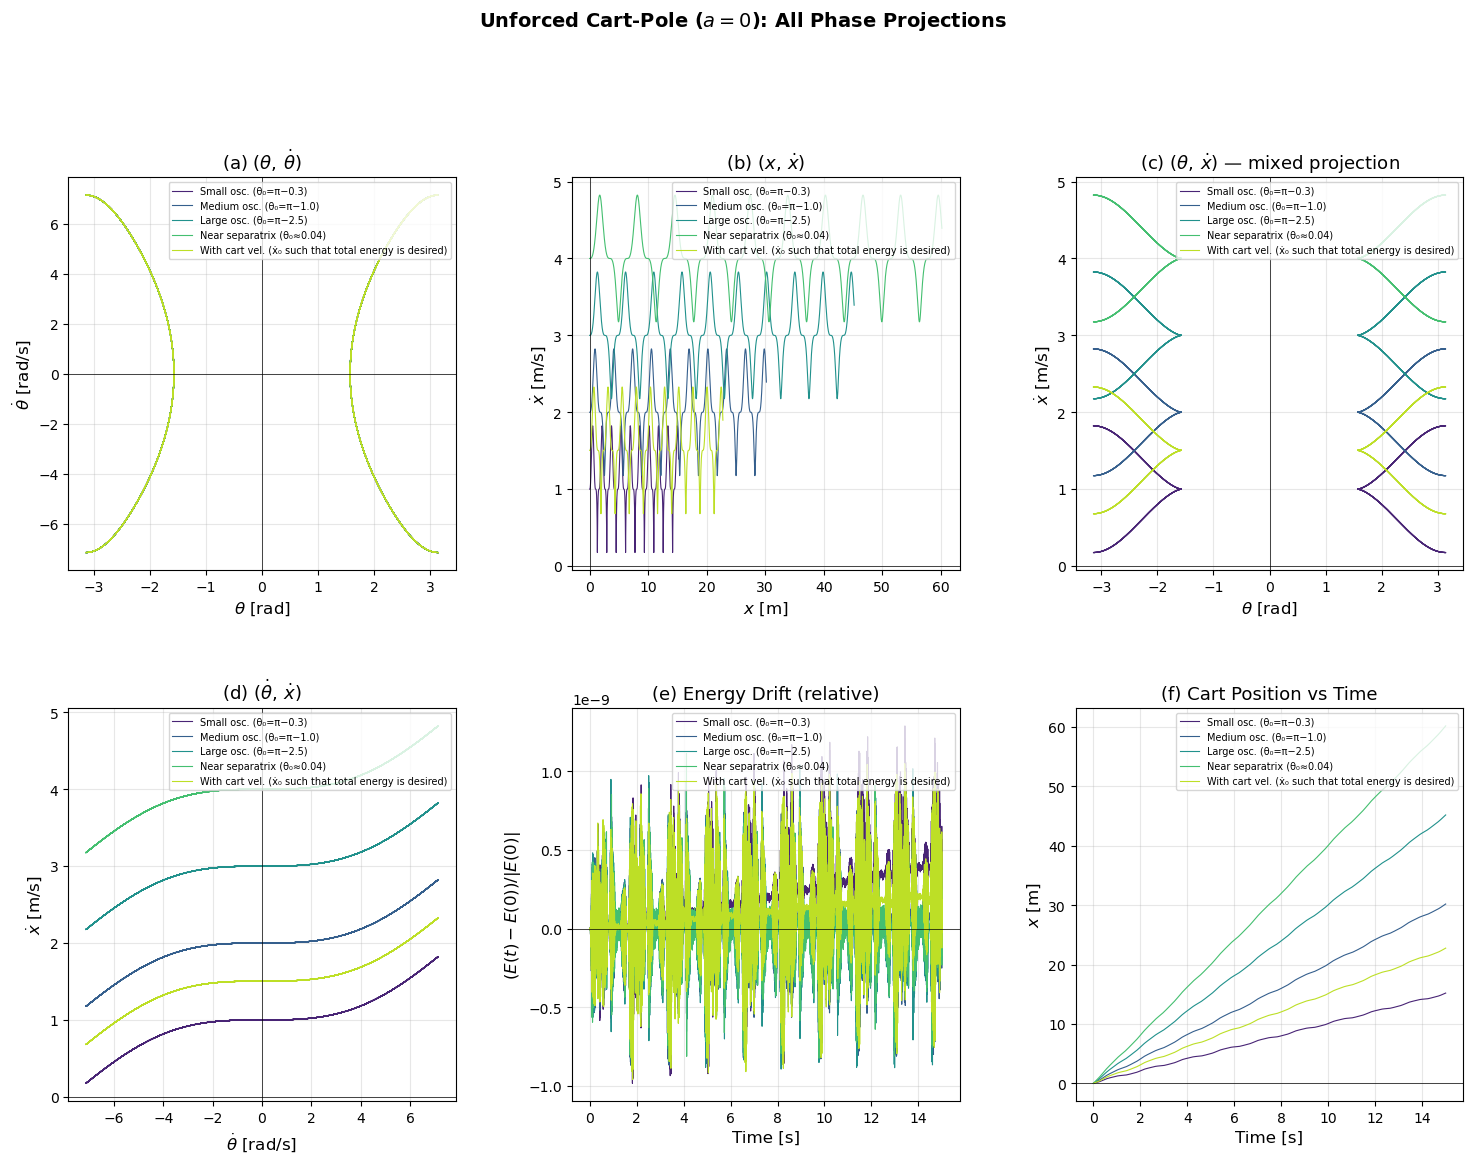

In [77]:
# Cell — REPLACE the phase portrait cell (fixes vertical lines + adds new projections)

def split_at_wraps(th, *others, threshold=5.0):
    """
    Split arrays at points where theta wraps around.
    Returns list of segments.
    """
    dth = np.abs(np.diff(th))
    wrap_idx = np.where(dth > threshold)[0] + 1
    indices = np.concatenate(([0], wrap_idx, [len(th)]))
    segments = []
    for i in range(len(indices) - 1):
        s = slice(indices[i], indices[i + 1])
        segments.append((th[s],) + tuple(o[s] for o in others))
    return segments


fig = plt.figure(figsize=(18, 12))
gs = GridSpec(2, 3, hspace=0.35, wspace=0.3)

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(results)))

# ── (a) Pendulum phase portrait (θ, θ̇) — with broken wraps ──
ax1 = fig.add_subplot(gs[0, 0])
for r, c in zip(results, colors):
    sol = r["sol"]
    th_wrapped = (sol.y[2] + np.pi) % (2 * np.pi) - np.pi
    segments = split_at_wraps(th_wrapped, sol.y[3])
    for i, (th_seg, thd_seg) in enumerate(segments):
        ax1.plot(th_seg, thd_seg, color=c, linewidth=0.8,
                 label=r["label"] if i == 0 else None)

ax1.set_xlabel(r"$\theta$ [rad]", fontsize=12)
ax1.set_ylabel(r"$\dot{\theta}$ [rad/s]", fontsize=12)
ax1.set_title(r"(a) $(\theta,\,\dot\theta)$", fontsize=13)
ax1.legend(fontsize=7, loc="upper right")
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color="k", linewidth=0.5)
ax1.axvline(0, color="k", linewidth=0.5)

# ── (b) Cart phase portrait (x, ẋ) ──
ax2 = fig.add_subplot(gs[0, 1])
for r, c in zip(results, colors):
    sol = r["sol"]
    ax2.plot(sol.y[0], sol.y[1], color=c, linewidth=0.8, label=r["label"])

ax2.set_xlabel(r"$x$ [m]", fontsize=12)
ax2.set_ylabel(r"$\dot{x}$ [m/s]", fontsize=12)
ax2.set_title(r"(b) $(x,\,\dot{x})$", fontsize=13)
ax2.legend(fontsize=7, loc="upper right")
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color="k", linewidth=0.5)
ax2.axvline(0, color="k", linewidth=0.5)

# ── (c) Mixed phase portrait (θ, ẋ) ──
ax3 = fig.add_subplot(gs[0, 2])
for r, c in zip(results, colors):
    sol = r["sol"]
    th_wrapped = (sol.y[2] + np.pi) % (2 * np.pi) - np.pi
    segments = split_at_wraps(th_wrapped, sol.y[1])
    for i, (th_seg, xd_seg) in enumerate(segments):
        ax3.plot(th_seg, xd_seg, color=c, linewidth=0.8,
                 label=r["label"] if i == 0 else None)

ax3.set_xlabel(r"$\theta$ [rad]", fontsize=12)
ax3.set_ylabel(r"$\dot{x}$ [m/s]", fontsize=12)
ax3.set_title(r"(c) $(\theta,\,\dot{x})$ — mixed projection", fontsize=13)
ax3.legend(fontsize=7, loc="upper right")
ax3.grid(True, alpha=0.3)
ax3.axhline(0, color="k", linewidth=0.5)
ax3.axvline(0, color="k", linewidth=0.5)

# ── (d) Mixed phase portrait (θ̇, ẋ) ──
ax4 = fig.add_subplot(gs[1, 0])
for r, c in zip(results, colors):
    sol = r["sol"]
    ax4.plot(sol.y[3], sol.y[1], color=c, linewidth=0.8, label=r["label"])

ax4.set_xlabel(r"$\dot{\theta}$ [rad/s]", fontsize=12)
ax4.set_ylabel(r"$\dot{x}$ [m/s]", fontsize=12)
ax4.set_title(r"(d) $(\dot\theta,\,\dot{x})$", fontsize=13)
ax4.legend(fontsize=7, loc="upper right")
ax4.grid(True, alpha=0.3)
ax4.axhline(0, color="k", linewidth=0.5)
ax4.axvline(0, color="k", linewidth=0.5)

# ── (e) Total energy vs time ──
ax5 = fig.add_subplot(gs[1, 1])
for r, c in zip(results, colors):
    sol = r["sol"]
    E_rel = (r["E_total"] - r["E_total"][0]) / (np.abs(r["E_total"][0]) + 1e-12)
    ax5.plot(sol.t, E_rel, color=c, linewidth=0.8, label=r["label"])

ax5.set_xlabel("Time [s]", fontsize=12)
ax5.set_ylabel(r"$(E(t) - E(0))/|E(0)|$", fontsize=12)
ax5.set_title("(e) Energy Drift (relative)", fontsize=13)
ax5.legend(fontsize=7, loc="upper right")
ax5.grid(True, alpha=0.3)
ax5.axhline(0, color="k", linewidth=0.5)
ax5.ticklabel_format(style="sci", axis="y", scilimits=(-2, 2))

# ── (f) Cart position vs time ──
ax6 = fig.add_subplot(gs[1, 2])
for r, c in zip(results, colors):
    sol = r["sol"]
    ax6.plot(sol.t, sol.y[0], color=c, linewidth=0.8, label=r["label"])

ax6.set_xlabel("Time [s]", fontsize=12)
ax6.set_ylabel(r"$x$ [m]", fontsize=12)
ax6.set_title("(f) Cart Position vs Time", fontsize=13)
ax6.legend(fontsize=7, loc="upper right")
ax6.grid(True, alpha=0.3)
ax6.axhline(0, color="k", linewidth=0.5)

plt.suptitle(
    "Unforced Cart-Pole ($a=0$): All Phase Projections",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.savefig("phase_portraits_unforced.png", dpi=150, bbox_inches="tight")
plt.show()

The most interesting part from this is $\theta$-$\dot\theta$ phase portrait. We checked several initial values $\dot x$ and all of them produced same portraits. This shows that initial energy from the cart does not transfered to the pendulum. Thus, for non-zero initial velocity of the cart $\dot x$

### 3.3 Observations from Phase Portraits

**Pendulum $(\theta, \dot\theta)$ — panel (a):**
- Trajectories form **nearly closed orbits** → approximately periodic in $\theta$

**Cart $(x, \dot{x})$ — panel (b):**
- Trajectories are NOT closed — $x$ drifts, confirming marginal stability of the cart position

**Mixed projections — panels (c) and (d):**
- $(\theta, \dot{x})$ shows **closed or nearly closed curves** — this means $\dot{x}$ IS periodic even though $x$ is not!
- $(\dot\theta, \dot{x})$ also shows closed curves — the velocity subspace $(\dot{x}, \dot\theta, \theta)$ has periodic structure

**Key insight from panel (c):**
The cart velocity $\dot{x}$ is periodic — it oscillates as the pendulum swings.
But its integral (cart position $x$) accumulates a nonzero mean drift per cycle,
which is why $x$ grows without bound. This is analogous to a sinusoid with a
DC offset: $\dot{x}(t) \approx A\sin(\omega t) + \bar{v}$, where $\bar{v} \neq 0$
in general.

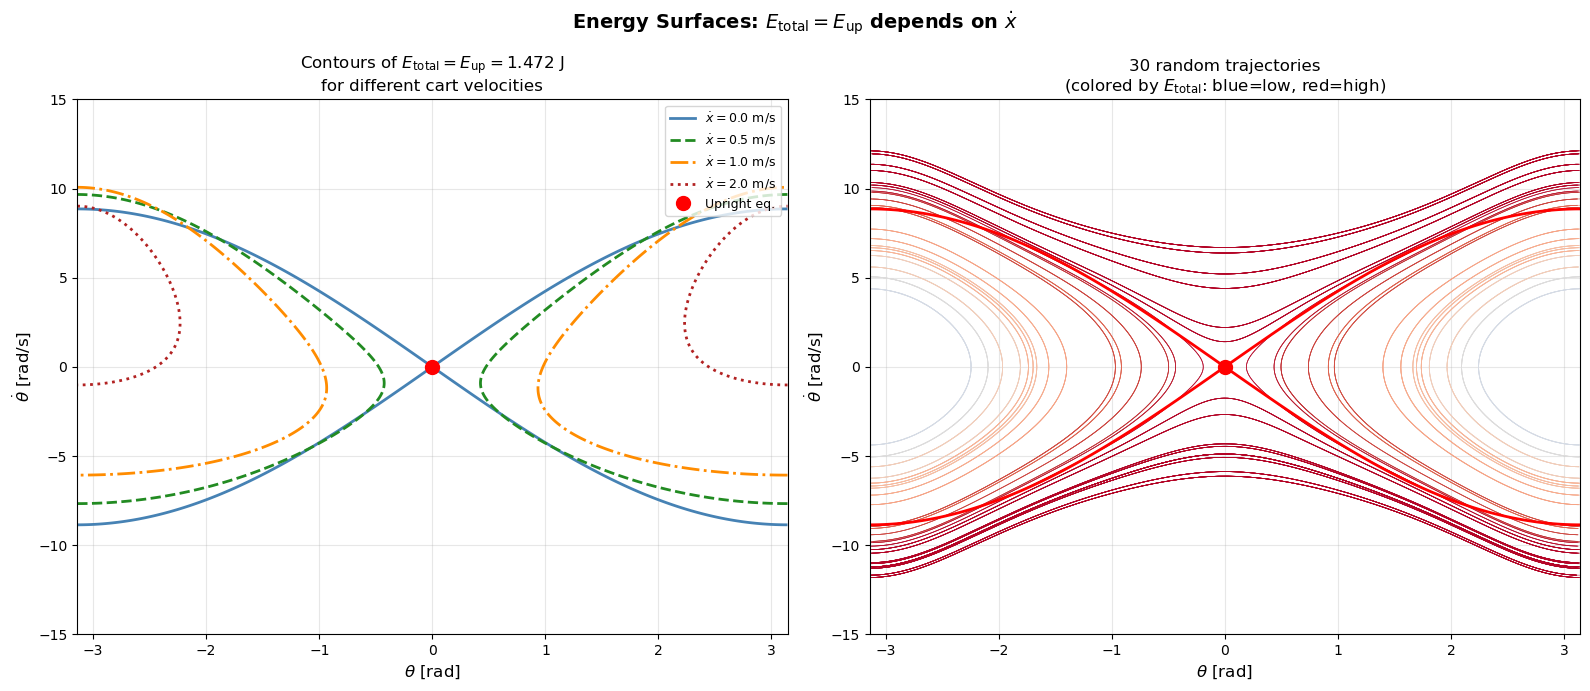

In [ ]:
# Cell — REPLACE the fixed-pivot comparison with energy surface analysis

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

mp_v, l_v, g_v = params["m_p"], params["l"], params["g"]
E_up_val = mp_v * g_v * l_v  # upright energy in Lagrangian convention

# ── Left: Total energy contours in (θ, θ̇) for various ẋ values ──
ax = axes[0]
th_grid = np.linspace(-np.pi, np.pi, 400)
thd_grid = np.linspace(-15, 15, 400)
TH, THD = np.meshgrid(th_grid, thd_grid)

mc_v = params["m_c"]

x_dot_values = [0.0, 0.5, 1.0, 2.0]
line_styles = ["-", "--", "-.", ":"]
color_list = ["steelblue", "forestgreen", "darkorange", "firebrick"]

for xd_val, ls, col in zip(x_dot_values, line_styles, color_list):
    # E_total(x_dot=xd_val, theta, theta_dot)
    T_grid = (0.5 * (mc_v + mp_v) * xd_val**2
              + 0.5 * mp_v * l_v**2 * THD**2
              + mp_v * l_v * xd_val * THD * np.cos(TH))
    V_grid = mp_v * g_v * l_v * np.cos(TH)
    E_grid = T_grid + V_grid

    # Contour at E = E_up
    cs = ax.contour(TH, THD, E_grid, levels=[E_up_val],
                    colors=col, linewidths=2.0, linestyles=ls)
    # Label
    ax.plot([], [], color=col, linestyle=ls, linewidth=2.0,
            label=rf"$\dot{{x}} = {xd_val}$ m/s")

ax.plot(0, 0, "ro", markersize=10, zorder=5, label="Upright eq.")
ax.set_xlabel(r"$\theta$ [rad]", fontsize=12)
ax.set_ylabel(r"$\dot{\theta}$ [rad/s]", fontsize=12)
ax.set_title(
    rf"Contours of $E_{{\text{{total}}}} = E_{{\text{{up}}}} = {E_up_val:.3f}$ J"
    + "\nfor different cart velocities",
    fontsize=12,
)
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-15, 15)
ax.grid(True, alpha=0.3)

# ── Right: Numerical trajectories colored by E_total ──
ax = axes[1]

# Simulate from many initial conditions
np.random.seed(42)
n_traj = 30
t_span_short = (0, 10)
t_eval_short = np.linspace(*t_span_short, 3000)

for i in range(n_traj):
    th0 = np.random.uniform(-np.pi, np.pi)
    thd0 = np.random.uniform(-8, 8)
    xd0 = np.random.uniform(0, 5)
    ic = [0.0, xd0, th0, thd0]

    sol = solve_ivp(
        cart_pole_dynamics, t_span_short, ic,
        args=(params,), t_eval=t_eval_short,
        method="RK45", rtol=1e-10, atol=1e-12,
    )

    E0 = total_energy(ic, params)
    # Color by energy relative to E_up
    E_ratio = (E0 - (-mp_v * g_v * l_v)) / (3 * mp_v * g_v * l_v)
    E_ratio = np.clip(E_ratio, 0, 1)
    col = plt.cm.coolwarm(E_ratio)

    th_wrapped = (sol.y[2] + np.pi) % (2 * np.pi) - np.pi
    segments = split_at_wraps(th_wrapped, sol.y[3])
    for th_seg, thd_seg in segments:
        ax.plot(th_seg, thd_seg, color=col, linewidth=0.5, alpha=0.7)

# Mark the E=E_up contour for x_dot=0 as reference
T_grid_0 = 0.5 * mp_v * l_v**2 * THD**2
V_grid_0 = mp_v * g_v * l_v * np.cos(TH)
E_grid_0 = T_grid_0 + V_grid_0
ax.contour(TH, THD, E_grid_0, levels=[E_up_val],
           colors="red", linewidths=2.0, linestyles="-")

ax.plot(0, 0, "ro", markersize=10, zorder=5)
ax.set_xlabel(r"$\theta$ [rad]", fontsize=12)
ax.set_ylabel(r"$\dot{\theta}$ [rad/s]", fontsize=12)
ax.set_title(
    "30 random trajectories\n"
    r"(colored by $E_{\text{total}}$: blue=low, red=high)",
    fontsize=12,
)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-15, 15)
ax.grid(True, alpha=0.3)

plt.suptitle(
    r"Energy Surfaces: $E_{\text{total}} = E_{\text{up}}$ depends on $\dot{x}$",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.savefig("energy_surfaces.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.5 The Energy Surface Is NOT a Simple Separatrix

**Panel (a)** above shows a crucial subtlety: the contour $E_{\text{total}} = E_{\text{up}}$
in the $(\theta, \dot\theta)$ plane **depends on the cart velocity $\dot{x}$**.

- At $\dot{x} = 0$: the contour passes through the upright point $(0, 0)$ — this
  looks like a classical separatrix
- At $\dot{x} \neq 0$: the contour **shifts** because kinetic energy is stored in
  the cart, leaving less energy available for the pendulum

**This means:**
- $E_{\text{total}} = E_{\text{up}}$ is a **3D surface** in $(\theta, \dot\theta, \dot{x})$ space,
  not a simple curve
- The "separatrix" concept from the simple pendulum does not directly transfer
- Our control goal is to reach this **energy surface**, and then use LQR
  to converge to the specific point $(x=0,\,\dot{x}=0,\,\theta=0,\,\dot\theta=0)$ on it

**Panel (b)** shows 30 random trajectories of the full coupled system. Each trajectory
stays on its own energy level (conservation), but the projection into $(\theta, \dot\theta)$
is influenced by the coupling with $\dot{x}$.

### 3.6 Summary: What This Means for Control

| What we proved | Why it matters for control |
|----------------|--------------------------|
| $E_{\text{total}}$ is conserved ($a=0$) | System is marginally stable — small control can reshape energy |
| All velocities are bounded | System won't blow up — controller always has a chance |
| $\dot{E}_{\text{total}} = a\dot{x}$ | Direct handle for energy shaping |
| $E_{\text{total}} = E_{\text{up}}$ is a reachable surface | Energy-based control can target it |

We do **not** need to prove exact periodicity or identify an exact separatrix.
The Lyapunov argument (Section 5) only requires $\dot{E}_{\text{total}} = u\dot{x}$,
which we proved exactly and without any approximation.

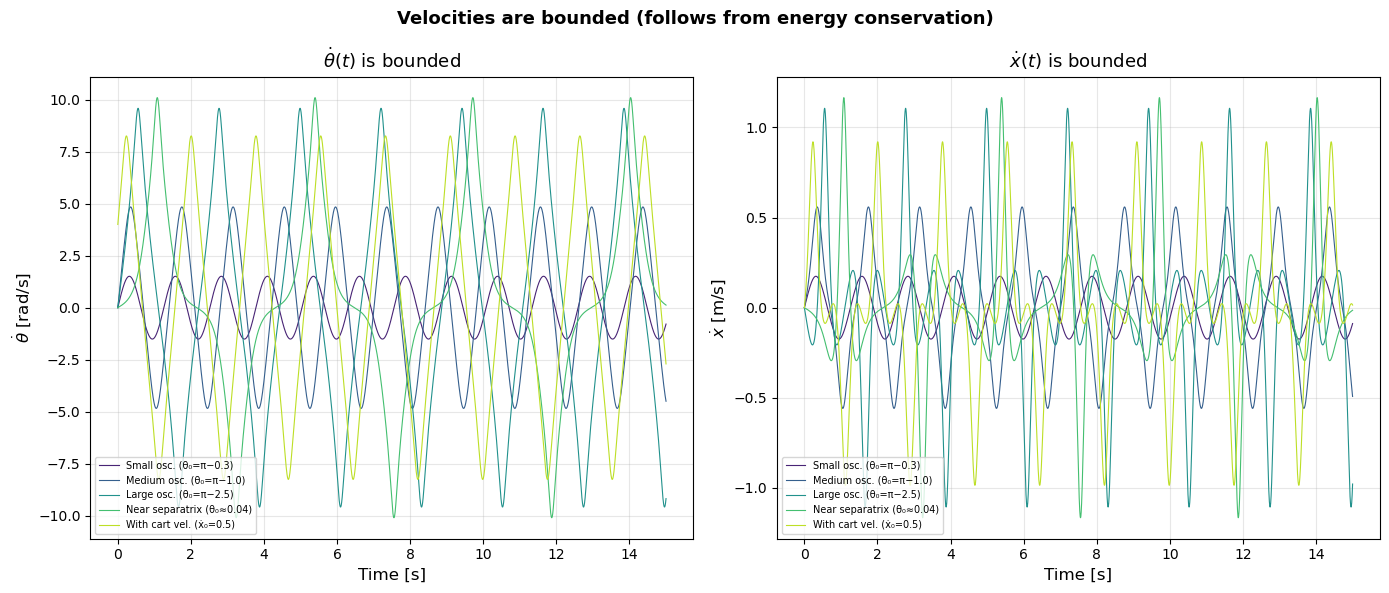

Velocity bounds from simulation:
  Small osc. (θ₀=π−0.3)         :  |θ̇|_max =  1.509 rad/s,  |ẋ|_max =  0.174 m/s
  Medium osc. (θ₀=π−1.0)        :  |θ̇|_max =  4.843 rad/s,  |ẋ|_max =  0.559 m/s
  Large osc. (θ₀=π−2.5)         :  |θ̇|_max =  9.585 rad/s,  |ẋ|_max =  1.106 m/s
  Near separatrix (θ₀≈0.04)     :  |θ̇|_max = 10.099 rad/s,  |ẋ|_max =  1.165 m/s
  With cart vel. (ẋ₀=0.5)       :  |θ̇|_max =  8.257 rad/s,  |ẋ|_max =  0.985 m/s


In [18]:
# Cell — REPLACE autocorrelation, fixed-pivot, three-regimes, elliptic integral cells
# with this single verification cell

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: verify that θ̇ and ẋ are bounded ──
ax = axes[0]
for r, c in zip(results, colors):
    sol = r["sol"]
    ax.plot(sol.t, sol.y[3], color=c, linewidth=0.8, label=r["label"])

ax.set_xlabel("Time [s]", fontsize=12)
ax.set_ylabel(r"$\dot{\theta}$ [rad/s]", fontsize=12)
ax.set_title(r"$\dot\theta(t)$ is bounded", fontsize=13)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

ax = axes[1]
for r, c in zip(results, colors):
    sol = r["sol"]
    ax.plot(sol.t, sol.y[1], color=c, linewidth=0.8, label=r["label"])

ax.set_xlabel("Time [s]", fontsize=12)
ax.set_ylabel(r"$\dot{x}$ [m/s]", fontsize=12)
ax.set_title(r"$\dot{x}(t)$ is bounded", fontsize=13)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.suptitle(
    "Velocities are bounded (follows from energy conservation)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig("bounded_velocities.png", dpi=150, bbox_inches="tight")
plt.show()

# Print bounds
print("Velocity bounds from simulation:")
for r in results:
    sol = r["sol"]
    print(f"  {r['label']:30s}:  "
          f"|θ̇|_max = {np.max(np.abs(sol.y[3])):6.3f} rad/s,  "
          f"|ẋ|_max = {np.max(np.abs(sol.y[1])):6.3f} m/s")

---
## 4. Energy–Velocity Relation: $\dot{E}_{\text{total}} = a\dot{x}$

This is the central identity that makes the full-energy Lyapunov design elegant.

**Claim:** For the cart-pole system with external force $a$ on the cart:

$$\dot{E}_{\text{total}} = a\,\dot{x}$$

*Physical meaning:* the rate of change of total energy equals the **power delivered by the actuator** (force × velocity).

In [19]:
print("We already computed:")
display(Math(r"\dot{E}_{\text{total}} = " + latex(E_dot_simplified)))

We already computed:


<IPython.core.display.Math object>

**Why this works intuitively:**

The only external force is $a$, applied to the cart at velocity $\dot{x}$.

- Power in = $a \cdot \dot{x}$
- Internal forces (gravity, constraint) are conservative — they redistribute energy between $T$ and $V$ but do not change the total.

This identity holds **exactly** — no linearization, no approximation.

---
## 5. Lyapunov Control Design

### 5.1 Desired Equilibrium Energy

At the upright equilibrium $(\theta = 0,\;\dot\theta = 0,\;\dot x = 0)$:

$$E_{\text{up}} = T\big|_{\text{eq}} + V\big|_{\text{eq}} = 0 + m_p g l\cos(0) = m_p g l$$

### 5.2 Lyapunov Candidate

Define the **energy error:**

$$\tilde{E} \triangleq E_{\text{total}} - E_{\text{up}}$$

and the **Lyapunov function:**

$$V_L = \frac{1}{2}\tilde{E}^{\,2} = \frac{1}{2}(E_{\text{total}} - E_{\text{up}})^2$$

**Properties:**
- $V_L \geq 0$ for all states (it is a square)
- $V_L = 0 \iff E_{\text{total}} = E_{\text{up}}$ (energy at the desired level)

### 5.3 Time Derivative of $V_L$

Using the chain rule:

$$\dot{V}_L = \tilde{E}\;\dot{E}_{\text{total}}$$

Substituting $\dot{E}_{\text{total}} = a\dot{x}$:

$$\dot{V}_L = \tilde{E}\;a\;\dot{x}$$

### 5.4 Control Law: Choose $u$ to Make $\dot{V}_L \leq 0$

We need $\dot{V}_L = \tilde{E}\;a\;\dot{x} \leq 0$.

**Choose:**

$$\boxed{a = -k_E\;\tilde{E}\;\dot{x}, \qquad k_E > 0}$$

In [20]:
print("Proposed control law:")
display(Math(r"a = -k_E\;\tilde{E}\;\dot{x}"))

print("\nSubstitute into dV_L/dt:")

# Symbolic computation
a_proposed = -k_E * E_tilde * x_d
V_L_dot = E_tilde * a_proposed * x_d

print("  Before simplification:")
display(Math(r"\dot{V}_L = \tilde{E}\cdot(-k_E\tilde{E}\dot{x})\cdot\dot{x}"))

V_L_dot_expanded = sp.expand(V_L_dot)
print("\n  After expanding:")
display(Math(r"\dot{V}_L = " + latex(V_L_dot_expanded)))

Proposed control law:


<IPython.core.display.Math object>


Substitute into dV_L/dt:
  Before simplification:


<IPython.core.display.Math object>


  After expanding:


<IPython.core.display.Math object>

### 5.5 Result

$$\boxed{\dot{V}_L = -k_E\;\tilde{E}^{\,2}\;\dot{x}^2 \;\leq\; 0 \quad \forall\;\text{states}}$$

Since:
- $k_E > 0$ (design parameter)
- $\tilde{E}^{\,2} \geq 0$ (square of a real number)
- $\dot{x}^2 \geq 0$ (square of a real number)

the product is always non-negative, and the minus sign guarantees $\dot{V}_L \leq 0$.

**The Lyapunov function is non-increasing along all trajectories.**

---
## 6. Convergence via LaSalle's Invariance Principle

$\dot{V}_L \leq 0$ tells us that $V_L$ is non-increasing, but does the system actually converge to $E_{\text{total}} = E_{\text{up}}$?

We apply **LaSalle's invariance principle**: the system converges to the largest **invariant set** contained in $\{\dot{V}_L = 0\}$.

### 6.1 Where is $\dot{V}_L = 0$?

$$\dot{V}_L = -k_E\,\tilde{E}^{\,2}\,\dot{x}^2 = 0$$

This holds when **either:**

| Condition | Meaning |
|-----------|---------|
| $\tilde{E} = 0$ | $E_{\text{total}} = E_{\text{up}}$ — **goal** |
| $\dot{x} = 0$ | Cart is momentarily stationary |

### 6.2 Is $\{\dot{x} \equiv 0\}$ invariant?

Suppose $\dot{x}(t) \equiv 0$ for all $t$. Then $\ddot{x}(t) \equiv 0$.

**From our control law:** $u = -k_E\tilde{E}\cdot 0 = 0$

**From the $x$-equation of motion** (with $u = 0$, $\ddot{x} = 0$):

$$m_p l\bigl(\ddot\theta\cos\theta - \dot\theta^2\sin\theta\bigr) = 0$$

$$\Longrightarrow \quad \frac{d}{dt}\bigl(\dot\theta\cos\theta\bigr) = 0 \quad \Longrightarrow \quad \dot\theta\cos\theta = C$$

**From the $\theta$-equation of motion** (with $\ddot{x} = 0$):

$$l\ddot\theta = g\sin\theta$$

This is a **free pendulum** equation. Multiplying by $\dot\theta$:

$$\frac{d}{dt}\Bigl(\frac{1}{2}l\dot\theta^2 + g\cos\theta\Bigr) = 0$$

Together with $\dot\theta\cos\theta = C$, this is only consistent for all time if **$C = 0$**, which requires $\dot\theta = 0$ (or $\cos\theta = 0$, but that leads to contradictions with $l\ddot\theta = g\sin\theta$).

$\dot\theta = 0$ and $l\ddot\theta = g\sin\theta$ together require $\sin\theta = 0$, so $\theta = 0$ or $\theta = \pi$.

**At $\theta = \pi$** (hanging down): $E_{\text{total}} = -m_pgl \neq E_{\text{up}} = m_pgl$, so $\tilde{E} \neq 0$. This means $\dot{V}_L < 0$ whenever $\dot{x} \neq 0$ — the system is **pushed away** from this state by the controller.

**At $\theta = 0$** (upright): $E_{\text{total}} = m_pgl = E_{\text{up}}$, so $\tilde{E} = 0$ — this is our **goal**. ✓

### 6.3 Conclusion

The largest invariant set inside $\{\dot{V}_L = 0\}$ is:

$$\mathcal{M} = \bigl\{(x,\dot{x},\theta,\dot\theta) : E_{\text{total}} = E_{\text{up}}\bigr\}$$

By **LaSalle's invariance principle:**

$$\boxed{E_{\text{total}}(t) \;\longrightarrow\; E_{\text{up}} \quad \text{as} \quad t \to \infty}$$

In [21]:
print("Check: if x_dot ≡ 0, then a = 0, and from x-EOM with x_ddot = 0:")
print()

# x-EOM with u=0 and x_dd=0
EL_x_check = EL_x.subs(a, 0).subs(x_dd, 0)
EL_x_check = trigsimp(sp.expand(EL_x_check))

display(Math(r"0 = " + latex(EL_x_check)))

print("\nθ-EOM with x_ddot = 0:")
EL_theta_check = EL_theta.subs(x_dd, 0)
EL_theta_check = trigsimp(sp.expand(EL_theta_check))

display(Math(r"0 = " + latex(EL_theta_check)))

# Solve theta-EOM for theta_dd
theta_dd_free = solve(EL_theta_check, theta_dd)
print("\nSolving for theta_ddot:")
display(Math(r"\ddot{\theta} = " + latex(theta_dd_free[0])))

Check: if x_dot ≡ 0, then a = 0, and from x-EOM with x_ddot = 0:



<IPython.core.display.Math object>


θ-EOM with x_ddot = 0:


<IPython.core.display.Math object>


Solving for theta_ddot:


<IPython.core.display.Math object>

---
## 7. Saturation Robustness

### 7.1 The Problem

In practice, the actuator is bounded:

$$|a| \leq a_{\max}$$

The saturated control is:

$$a_{\text{sat}} = \text{clip}\bigl(-k_E\tilde{E}\dot{x},\;-a_{\max},\;+a_{\max}\bigr)$$

**Question:** Does $\dot{V}_L \leq 0$ still hold?

### 7.2 Proof

With the saturated control:

$$\dot{V}_L = \tilde{E}\;a_{\text{sat}}\;\dot{x}$$

The **ideal** control is $a^* = -k_E\tilde{E}\dot{x}$, so:

$$\text{sign}(a^*) = -\text{sign}(\tilde{E}\;\dot{x})$$

Saturation (clipping) **reduces magnitude but preserves sign:**

$$\text{sign}(a_{\text{sat}}) = \text{sign}(a^*) = -\text{sign}(\tilde{E}\;\dot{x})$$

Therefore:

$$\tilde{E}\;a_{\text{sat}}\;\dot{x}
\;=\; \bigl|\tilde{E}\;\dot{x}\bigr| \;\cdot\; \underbrace{\text{sign}(\tilde{E}\;\dot{x})\;\cdot\;a_{\text{sat}}}_{\leq\;0}
\;\leq\; 0$$

### 7.3 Result

$$\boxed{\dot{V}_L \leq 0 \quad \text{for ANY } a_{\max} > 0, \text{ unconditionally}}$$

**No conditions on:**
- Magnitude of $a_{\max}$
- System parameters
- Controller gain $k_E$
- Current state

This is a fundamental advantage of the **total energy** formulation over the pendulum-only energy approach.

# 8 Pendulum Energy based Controller

## 8.1 Controller derivation

In [91]:
# Cell N — Pendulum Energy Lyapunov Analysis

E_tild = sp.symbols("\\tilde{E}")

# === Pendulum Energy ===
E_p = Rational(1, 2) * m_p * l**2 * theta_d**2 + m_p * g * l * (1+cos(theta))
E_des = 2*m_p * g * l

print("Pendulum energy:")
display(Math(r"E_p = " + latex(E_p)))

print("\nDesired energy (upright equilibrium):")
display(Math(r"E_{\mathrm{des}} = " + latex(E_des)))

E_tilde_expr = trigsimp(E_p - E_des)
print("\nEnergy error:")
display(Math(r"\tilde{E} = E_p - E_{\mathrm{des}} = " + latex(E_tilde_expr)))

# === Lyapunov Function ===
print("\nWe choose the Lyapunov candidate:")
display(Math(r"V_P = \frac{1}{2}\tilde{E}^2"))

# === Time Derivative of E_p ===
print("\nComputing time derivative of E_p:")
E_p_dot = diff(E_p, t)
E_p_dot = trigsimp(expand(E_p_dot))
display(Math(r"\dot{E}_p \text{ (raw)} = " + latex(E_p_dot)))

# Substitute theta_ddot from the pendulum Euler-Lagrange equation
print("\nSubstituting theta_ddot from the pendulum equation of motion:")
E_p_dot = trigsimp(simplify(E_p_dot.subs(theta_dd, theta_dd_expr)))
display(Math(r"\dot{E}_p = " + latex(E_p_dot)))

# === Time Derivative of V_P ===
print("\nTime derivative of the Lyapunov function:")
V_P_dot = trigsimp(expand(E_tilde_expr * E_p_dot))
display(Math(r"\dot{V}_P = \tilde{E} \cdot \dot{E}_p = " + latex(V_P_dot)))

# === Controller Design ===
print("\nTo ensure dV_P/dt <= 0, we treat u = x_ddot as the control input.")
print("Rewriting dV_P/dt in terms of u:")
display(Math(r"\dot{V}_P = -m_p l \tilde{E} \cdot u \cdot \dot{\theta} \cos\theta"))

print("\nWe choose the control law:")
u_control = k_E * E_tilde_expr * theta_d * cos(theta)
display(Math(r"u = k_E \tilde{E} \dot{\theta} \cos\theta = " + latex(u_control)))

print("\nSubstituting into dV_P/dt:")
V_P_dot_controlled = trigsimp(simplify(
    E_tilde_expr * (-m_p * l * symbols("u") * theta_d * cos(theta))
    .subs(symbols("u"), u_control)
))
display(Math(r"\dot{V}_P = " + latex(V_P_dot_controlled)))

print("\nSince k_E, m_p, l > 0 and the remaining terms are squared:")
display(trigsimp(simplify(V_P_dot_controlled / E_tilde_expr**2)) * E_tild**2)

Pendulum energy:


<IPython.core.display.Math object>


Desired energy (upright equilibrium):


<IPython.core.display.Math object>


Energy error:


...

<IPython.core.display.Math object>


Substituting into dV_P/dt:


<IPython.core.display.Math object>


Since k_E, m_p, l > 0 and the remaining terms are squared:


-\tilde{E}**2*k_E*l*m_p*cos(theta(t))**2*Derivative(theta(t), t)**2

## 8.2 LaSalle principle 

We have established that the time derivative of the Lyapunov function satisfies

$$
\dot{V}_P = -k_E\,m_p\,l\,\tilde{E}^2\,\dot{\theta}^2\cos^2\theta \leq 0.
$$

To prove convergence, we apply **LaSalle's Invariance Principle**.  
The set where $\dot{V}_P = 0$ is defined by the union of three conditions:

| Condition | Meaning |
|---|---|
| $\tilde{E} = 0$ | Pendulum at desired energy level |
| $\dot{\theta} = 0$ | Zero angular velocity |
| $\cos\theta = 0$ | Pendulum horizontal ($\theta = \pm\pi/2$) |

We now find the **largest invariant set** $\mathcal{M} \subseteq \{\dot{V}_P = 0\}$.

---

**Case $\dot{\theta} \equiv 0$:**

If $\dot{\theta} \equiv 0$, then $\ddot{\theta} = 0$. Substituting into the pendulum dynamics:

$$
ml\ddot{x}\cos\theta - mgl\sin\theta = 0
\quad\Rightarrow\quad
\ddot{x} = g\tan\theta.
$$

But our control law gives $a = k_E\,\tilde{E}\,\dot{\theta}\cos\theta = 0$, hence $\ddot{x} = 0$.  
Therefore $g\tan\theta = 0$, which yields $\theta = 0$ or $\theta = \pi$.

| State | Energy | $\tilde{E}$ | Invariant? |
|---|---|---|---|
| $(\theta, \dot{\theta}) = (0, 0)$ | $E_p = 2mgl = E_{\text{des}}$ | $0$ ✓ | Yes |
| $(\theta, \dot{\theta}) = (\pi, 0)$ | $E_p = 0$ | $-2mgl$ | Yes (isolated) |

The downward equilibrium $(\pi, 0)$ is **unstable** — any perturbation activates the controller. Its basin of attraction has measure zero.

**Case $\cos\theta \equiv 0$:**

Requires $\theta \equiv \pm\pi/2$, so $\dot{\theta} \equiv 0$ and $\ddot{\theta} \equiv 0$.  
The pendulum dynamics then demand $\ddot{x} = g\tan(\pm\pi/2) = \pm\infty$, contradicting $\ddot{x} = 0$.  
**Not an invariant set.**

---

**Conclusion.** The largest invariant set is

$$
\mathcal{M} = \{(\theta, \dot{\theta}) : \tilde{E} = 0\} \;\cup\; \{(\pi, 0)\}.
$$

By LaSalle's Invariance Principle, all trajectories converge to $\mathcal{M}$.  
Since $(\pi, 0)$ is unstable with measure-zero attraction basin, **generic trajectories converge to the desired energy surface** $\tilde{E} = 0$.